# Laboratorio 03 — EDA clínico de una cohorte con diabetes tipo 2

## Objetivo

Construir un análisis exploratorio reproducible de una cohorte sintética de pacientes con diabetes tipo 2 generada con Synthea.

El análisis incluirá:

- definición explícita de la cohorte;
- descripción de características basales;
- evaluación de faltantes y calidad de datos;
- distribución de edad por sexo;
- evolución temporal de un biomarcador;
- comorbilidades más frecuentes;
- detección visual de problemas que no serían evidentes mediante `describe()`;
- construcción de una figura multipanel con calidad de publicación;
- comparación entre matplotlib, seaborn y plotly;
- elaboración de una Tabla 1;
- tres hallazgos finales expresados en lenguaje clínico.

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

pd.set_option("display.max_columns", 100)
pd.set_option("display.max_rows", 100)

sns.set_context("notebook")

In [2]:
DATA_DIR = Path("../lab02/output/csv")

archivos = sorted(p.name for p in DATA_DIR.glob("*.csv"))

print(f"Directorio: {DATA_DIR.resolve()}")
print(f"Número de archivos CSV: {len(archivos)}")

archivos

Directorio: /home/luis-enrique/Desktop/Datascience_BIomedicas/Labs - Clase - Tareas/lab02/output/csv
Número de archivos CSV: 18


['allergies.csv',
 'careplans.csv',
 'claims.csv',
 'claims_transactions.csv',
 'conditions.csv',
 'devices.csv',
 'encounters.csv',
 'imaging_studies.csv',
 'immunizations.csv',
 'medications.csv',
 'observations.csv',
 'organizations.csv',
 'patients.csv',
 'payer_transitions.csv',
 'payers.csv',
 'procedures.csv',
 'providers.csv',
 'supplies.csv']

## 1. Definición de la cohorte

Se analizará una cohorte de pacientes con **diabetes mellitus tipo 2**.

La cohorte se definirá a partir de los diagnósticos registrados en `conditions.csv`. Antes de seleccionar pacientes se inspeccionarán los códigos y descripciones presentes en los datos para identificar cómo representa Synthea la diabetes y evitar asumir previamente una codificación específica.

In [3]:
conditions = pd.read_csv(
    DATA_DIR / "conditions.csv",
    usecols=["PATIENT", "ENCOUNTER", "CODE", "DESCRIPTION", "START", "STOP"]
)

print("Dimensiones:", conditions.shape)

diabetes_desc = (
    conditions.loc[
        conditions["DESCRIPTION"].str.contains("diabet", case=False, na=False),
        ["CODE", "DESCRIPTION"]
    ]
    .value_counts()
    .reset_index(name="n")
)

diabetes_desc.head(30)

Dimensiones: (830799, 6)


,CODE,DESCRIPTION,n
0,714628002,Prediabetes (finding),8734
1,127013003,Disorder of kidney due to diabetes mellitus (d...,2246
2,90781000119102,Microalbuminuria due to type 2 diabetes mellit...,1903
3,44054006,Diabetes mellitus type 2 (disorder),1671
4,157141000119108,Proteinuria due to type 2 diabetes mellitus (d...,1372
5,368581000119106,Neuropathy due to type 2 diabetes mellitus (di...,506
6,1551000119108,Nonproliferative diabetic retinopathy due to t...,449
7,97331000119101,Macular edema and retinopathy due to type 2 di...,49
8,1501000119109,Proliferative diabetic retinopathy due to type...,28
9,60951000119105,Blindness due to type 2 diabetes mellitus (dis...,6


### 1.1 Criterio de inclusión

La cohorte principal se definió mediante el diagnóstico:

**SNOMED CT 44054006 — Diabetes mellitus type 2 (disorder)**

Se excluyó `Prediabetes (finding)` porque no representa diabetes tipo 2 establecida.

Los diagnósticos relacionados con nefropatía, proteinuria, neuropatía o retinopatía diabética no se utilizaron como criterio primario de inclusión; posteriormente se analizarán como complicaciones clínicas dentro de la cohorte.

Para cada paciente, la primera fecha registrada de diabetes tipo 2 se utilizará como **fecha índice**.

In [4]:
T2D_CODE = 44054006

t2d = conditions.loc[
    conditions["CODE"] == T2D_CODE,
    ["PATIENT", "START", "CODE", "DESCRIPTION"]
].copy()

t2d["START"] = pd.to_datetime(t2d["START"])

cohorte_t2d = (
    t2d
    .groupby("PATIENT", as_index=False)
    .agg(fecha_indice=("START", "min"))
)

print("Registros con diagnóstico T2D:", len(t2d))
print("Pacientes únicos con T2D:", cohorte_t2d["PATIENT"].nunique())
print("Primera fecha índice:", cohorte_t2d["fecha_indice"].min())
print("Última fecha índice:", cohorte_t2d["fecha_indice"].max())

cohorte_t2d.head()

Registros con diagnóstico T2D: 1671
Pacientes únicos con T2D: 1671
Primera fecha índice: 1943-09-02 00:00:00
Última fecha índice: 2026-08-06 00:00:00


,PATIENT,fecha_indice
0,00153af4-f1e5-c5f9-8283-62df7f291fea,2026-04-24
1,001a3960-e274-3b52-fbf3-cd19bda684b0,1997-08-12
2,003b9cb4-e24c-f4cd-e8ca-4780149546a8,2003-03-04
3,00521ed0-795b-e7f4-2db0-04e9f69726ae,2016-08-04
4,0053192d-63db-45ea-2941-caed248e43ee,1992-01-31


In [5]:
patients = pd.read_csv(
    DATA_DIR / "patients.csv",
    parse_dates=["BIRTHDATE", "DEATHDATE"]
)

cohorte = cohorte_t2d.merge(
    patients,
    left_on="PATIENT",
    right_on="Id",
    how="left",
    validate="one_to_one"
)

cohorte["edad_indice"] = (
    (cohorte["fecha_indice"] - cohorte["BIRTHDATE"]).dt.days / 365.25
)

print("Pacientes en cohorte:", len(cohorte))
print("Pacientes sin información demográfica:", cohorte["Id"].isna().sum())

cohorte[
    ["PATIENT", "fecha_indice", "BIRTHDATE", "edad_indice",
     "GENDER", "RACE", "ETHNICITY"]
].head()

Pacientes en cohorte: 1671
Pacientes sin información demográfica: 0


,PATIENT,fecha_indice,BIRTHDATE,edad_indice,GENDER,RACE,ETHNICITY
0,00153af4-f1e5-c5f9-8283-62df7f291fea,2026-04-24,1989-01-06,37.295003,M,white,nonhispanic
1,001a3960-e274-3b52-fbf3-cd19bda684b0,1997-08-12,1966-05-31,31.200548,F,black,nonhispanic
2,003b9cb4-e24c-f4cd-e8ca-4780149546a8,2003-03-04,1962-09-25,40.438056,F,white,nonhispanic
3,00521ed0-795b-e7f4-2db0-04e9f69726ae,2016-08-04,1968-07-11,48.065708,M,white,nonhispanic
4,0053192d-63db-45ea-2941-caed248e43ee,1992-01-31,1957-11-15,34.209446,F,white,hispanic


In [6]:
n_total = patients["Id"].nunique()
n_t2d_registros = len(t2d)
n_t2d_pacientes = cohorte_t2d["PATIENT"].nunique()
n_final = len(cohorte)

print(f"Pacientes totales en Synthea: {n_total:,}")
print(f"Registros de diagnóstico T2D: {n_t2d_registros:,}")
print(f"Pacientes únicos con T2D: {n_t2d_pacientes:,}")
print(f"Cohorte final con datos demográficos: {n_final:,}")

print("\nEdad al diagnóstico:")
print(cohorte["edad_indice"].describe().round(1))

Pacientes totales en Synthea: 22,851
Registros de diagnóstico T2D: 1,671
Pacientes únicos con T2D: 1,671
Cohorte final con datos demográficos: 1,671

Edad al diagnóstico:
count    1671.0
mean       47.4
std        12.1
min         0.7
25%        39.8
50%        47.4
75%        55.5
max        84.5
Name: edad_indice, dtype: float64


In [7]:
menores_18 = cohorte.loc[
    cohorte["edad_indice"] < 18,
    ["PATIENT", "fecha_indice", "BIRTHDATE", "edad_indice", "GENDER"]
].sort_values("edad_indice")

print(f"Pacientes T2D menores de 18 años: {len(menores_18):,}")
print(f"Proporción: {len(menores_18) / len(cohorte) * 100:.2f}%")

menores_18.head(20)

Pacientes T2D menores de 18 años: 3
Proporción: 0.18%


,PATIENT,fecha_indice,BIRTHDATE,edad_indice,GENDER
146,1839444c-d6b3-f6a2-a5ed-c14a53345705,1956-05-06,1955-08-28,0.689938,M
1588,f1d9725a-778a-371f-8116-c203c28941ad,2006-12-05,2003-07-01,3.430527,M
1564,ecad1594-f241-63d9-ea01-2557b2cab31b,1991-05-12,1978-04-16,13.070500,M


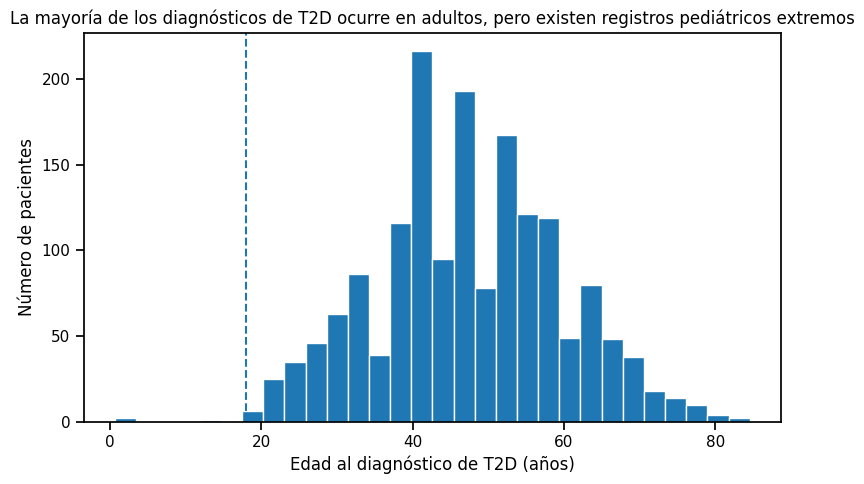

In [8]:
fig, ax = plt.subplots(figsize=(8, 5))

ax.hist(
    cohorte["edad_indice"],
    bins=30,
    edgecolor="white"
)

ax.axvline(18, linestyle="--", linewidth=1.5)

ax.set(
    xlabel="Edad al diagnóstico de T2D (años)",
    ylabel="Número de pacientes",
    title="La mayoría de los diagnósticos de T2D ocurre en adultos, "
          "pero existen registros pediátricos extremos"
)

fig.tight_layout()
plt.show()

### Hallazgo de calidad: diagnósticos pediátricos extremos

La distribución de edad al primer diagnóstico de diabetes mellitus tipo 2 muestra una cohorte predominantemente adulta. Sin embargo, se identificaron **3 pacientes menores de 18 años**, incluyendo registros a edades de **0.7, 3.4 y 13.1 años**.

Estos casos representan únicamente el **0.18%** de la cohorte inicial, pero son clínicamente atípicos para el objetivo de este análisis. Por ello, se excluyeron del análisis principal y se conservaron únicamente como hallazgo de calidad de datos.

La cohorte analítica final quedó restringida a pacientes adultos con diabetes mellitus tipo 2.

In [9]:
cohorte_adulta = cohorte.loc[
    cohorte["edad_indice"] >= 18
].copy()

print(f"Cohorte final adulta: {len(cohorte_adulta):,}")

Cohorte final adulta: 1,668


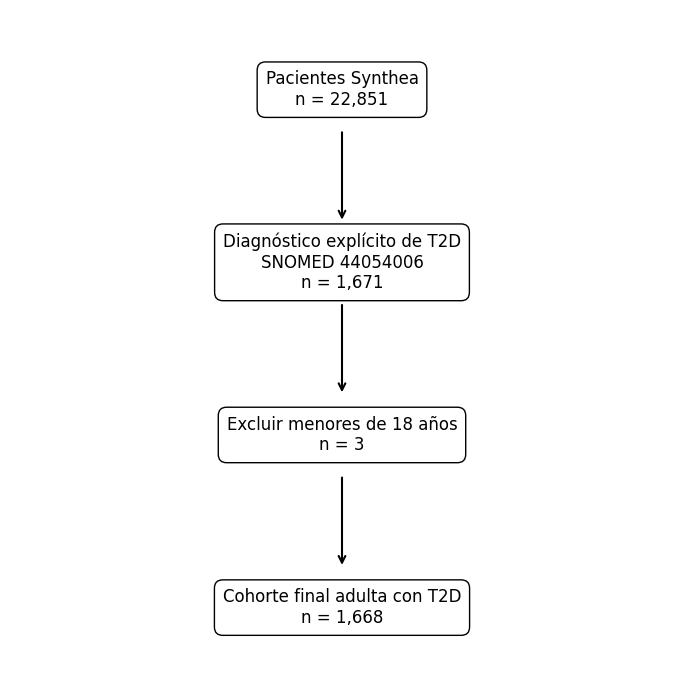

In [32]:
fig, ax = plt.subplots(figsize=(7, 7))

ax.text(0.5, 0.88, "Pacientes Synthea\nn = 22,851",
        ha="center", va="center", bbox=dict(boxstyle="round,pad=0.5", fc="white"))

ax.text(0.5, 0.62, "Diagnóstico explícito de T2D\nSNOMED 44054006\nn = 1,671",
        ha="center", va="center", bbox=dict(boxstyle="round,pad=0.5", fc="white"))

ax.text(0.5, 0.36, "Excluir menores de 18 años\nn = 3",
        ha="center", va="center", bbox=dict(boxstyle="round,pad=0.5", fc="white"))

ax.text(0.5, 0.10, "Cohorte final adulta con T2D\nn = 1,668",
        ha="center", va="center", bbox=dict(boxstyle="round,pad=0.5", fc="white"))

for y1, y2 in [(0.82, 0.68), (0.56, 0.42), (0.30, 0.16)]:
    ax.annotate("", xy=(0.5, y2), xytext=(0.5, y1),
                arrowprops=dict(arrowstyle="->", lw=1.5))

ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.axis("off")

fig.tight_layout()
plt.show()

In [10]:
print("Dimensiones:", cohorte_adulta.shape)
print("Pacientes únicos:", cohorte_adulta["PATIENT"].nunique())

print("\nDuplicados completos:")
print(cohorte_adulta.duplicated().sum())

print("\nValores faltantes:")
print(
    cohorte_adulta.isna()
    .sum()
    .sort_values(ascending=False)
    .head(15)
)

Dimensiones: (1668, 31)
Pacientes únicos: 1668

Duplicados completos:
0

Valores faltantes:
SUFFIX          1650
DEATHDATE       1299
MAIDEN          1017
FIPS             423
MIDDLE           336
MARITAL            5
fecha_indice       0
DRIVERS            0
SSN                0
BIRTHDATE          0
Id                 0
FIRST              0
PREFIX             0
PASSPORT           0
PATIENT            0
dtype: int64


In [11]:
DATA_DIR = Path("../lab02/output/csv")

archivos = sorted(p.name for p in DATA_DIR.glob("*.csv"))

print(f"Directorio: {DATA_DIR.resolve()}")
print(f"Número de archivos CSV: {len(archivos)}")

archivos

Directorio: /home/luis-enrique/Desktop/Datascience_BIomedicas/Labs - Clase - Tareas/lab02/output/csv
Número de archivos CSV: 18


['allergies.csv',
 'careplans.csv',
 'claims.csv',
 'claims_transactions.csv',
 'conditions.csv',
 'devices.csv',
 'encounters.csv',
 'imaging_studies.csv',
 'immunizations.csv',
 'medications.csv',
 'observations.csv',
 'organizations.csv',
 'patients.csv',
 'payer_transitions.csv',
 'payers.csv',
 'procedures.csv',
 'providers.csv',
 'supplies.csv']

In [12]:
print("\nTipos de datos:")
print(cohorte_adulta.dtypes)

faltantes_pct = (
    cohorte_adulta.isna()
    .mean()
    .mul(100)
    .sort_values(ascending=False)
)

print("\nPorcentaje de valores faltantes:")
print(faltantes_pct.head(15))


Tipos de datos:
PATIENT                        object
fecha_indice           datetime64[ns]
Id                             object
BIRTHDATE              datetime64[ns]
DEATHDATE              datetime64[ns]
SSN                            object
DRIVERS                        object
PASSPORT                       object
PREFIX                         object
FIRST                          object
MIDDLE                         object
LAST                           object
SUFFIX                         object
MAIDEN                         object
MARITAL                        object
RACE                           object
ETHNICITY                      object
GENDER                         object
BIRTHPLACE                     object
ADDRESS                        object
CITY                           object
STATE                          object
COUNTY                         object
FIPS                          float64
ZIP                             int64
LAT                           flo

### Resultado de la revisión estructural

La cohorte final contiene **1,668 pacientes únicos** y no presenta registros completamente duplicados, por lo que cada fila puede interpretarse como un paciente individual.

Los valores faltantes se concentran principalmente en variables administrativas o demográficas como `SUFFIX`, `MAIDEN`, `MIDDLE` y `FIPS`. La ausencia elevada en `DEATHDATE` es esperable, ya que corresponde a pacientes que permanecen vivos al final del periodo simulado.

Las variables clínicas principales para este análisis, incluyendo `fecha_indice`, `BIRTHDATE`, `GENDER`, `RACE` y `ETHNICITY`, presentan información prácticamente completa.

Antes de continuar con las visualizaciones se ajustarán los tipos de datos para que cada variable tenga una representación coherente con su significado.

## conversión a dtypes menos pesados

In [13]:
categoricas = [
    "MARITAL", "RACE", "ETHNICITY", "GENDER",
    "PREFIX", "STATE", "COUNTY"
]

for col in categoricas:
    cohorte_adulta[col] = cohorte_adulta[col].astype("category")

texto = [
    "PATIENT", "Id", "SSN", "DRIVERS", "PASSPORT",
    "FIRST", "MIDDLE", "LAST", "SUFFIX", "MAIDEN",
    "BIRTHPLACE", "ADDRESS", "CITY"
]

for col in texto:
    cohorte_adulta[col] = cohorte_adulta[col].astype("string")

print(cohorte_adulta.dtypes)

PATIENT                string[python]
fecha_indice           datetime64[ns]
Id                     string[python]
BIRTHDATE              datetime64[ns]
DEATHDATE              datetime64[ns]
SSN                    string[python]
DRIVERS                string[python]
PASSPORT               string[python]
PREFIX                       category
FIRST                  string[python]
MIDDLE                 string[python]
LAST                   string[python]
SUFFIX                 string[python]
MAIDEN                 string[python]
MARITAL                      category
RACE                         category
ETHNICITY                    category
GENDER                       category
BIRTHPLACE             string[python]
ADDRESS                string[python]
CITY                   string[python]
STATE                        category
COUNTY                       category
FIPS                          float64
ZIP                             int64
LAT                           float64
LON         

### 2.2 Patrón de datos faltantes

El porcentaje de valores faltantes indica qué variables están incompletas, pero no permite saber si esas ausencias ocurren de forma aleatoria o se concentran en determinados pacientes o variables.

Para detectar posibles patrones se visualizará la matriz de datos faltantes de la cohorte.

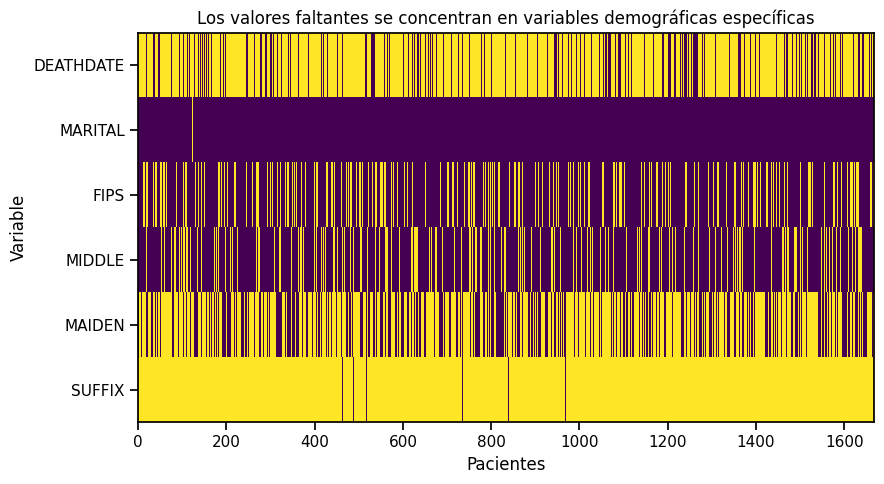

In [14]:
cols_missing = [
    "DEATHDATE",
    "MARITAL",
    "FIPS",
    "MIDDLE",
    "MAIDEN",
    "SUFFIX"
]

missing_matrix = cohorte_adulta[cols_missing].isna()

fig, ax = plt.subplots(figsize=(9, 5))

ax.imshow(
    missing_matrix.T,
    aspect="auto",
    interpolation="nearest"
)

ax.set(
    xlabel="Pacientes",
    ylabel="Variable",
    title="Los valores faltantes se concentran en variables demográficas específicas"
)

ax.set_yticks(range(len(cols_missing)))
ax.set_yticklabels(cols_missing)

fig.tight_layout()
plt.show()

### Resultado del patrón de datos faltantes

La visualización muestra que los datos faltantes se concentran principalmente en variables específicas y no forman grandes bloques evidentes de pacientes con información sistemáticamente ausente.

`SUFFIX` presenta ausencia casi universal, mientras que `MAIDEN` y `DEATHDATE` muestran una proporción elevada de faltantes. En contraste, `MARITAL` está prácticamente completo. `FIPS` y `MIDDLE` presentan ausencias dispersas a lo largo de la cohorte.

Este patrón sugiere que buena parte del missingness está asociado al significado o aplicabilidad de cada variable. Sin embargo, dado que el orden de los pacientes es arbitrario, esta gráfica por sí sola no permite concluir que los datos falten de manera aleatoria.

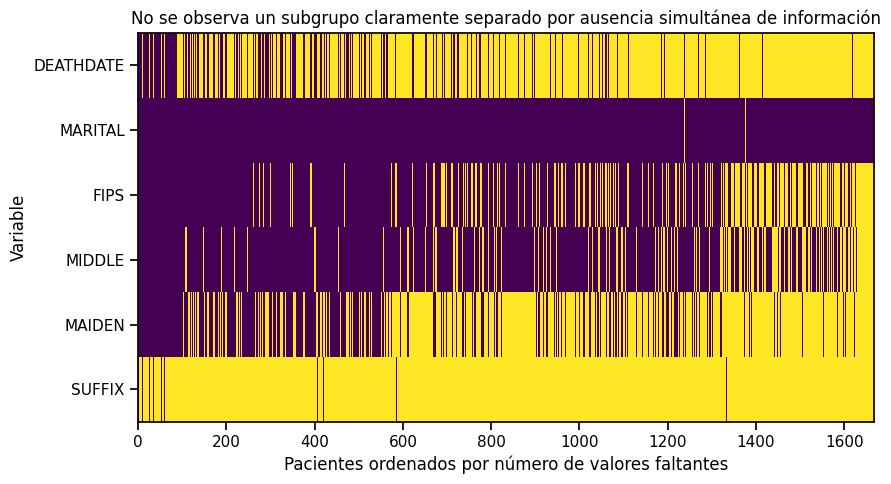

In [15]:
missing_ordenado = missing_matrix.loc[
    missing_matrix.sum(axis=1).sort_values().index
]

fig, ax = plt.subplots(figsize=(9, 5))

ax.imshow(
    missing_ordenado.T,
    aspect="auto",
    interpolation="nearest"
)

ax.set(
    xlabel="Pacientes ordenados por número de valores faltantes",
    ylabel="Variable",
    title="No se observa un subgrupo claramente separado por ausencia simultánea de información"
)

ax.set_yticks(range(len(cols_missing)))
ax.set_yticklabels(cols_missing)

fig.tight_layout()
plt.show()

### Resultado del patrón de datos faltantes

Al ordenar los pacientes según el número total de valores faltantes, no aparece un subgrupo claramente separado con pérdida simultánea de múltiples variables clínicas.

La ausencia sigue concentrándose principalmente en variables concretas:

- `SUFFIX` presenta faltantes casi universales. Corresponde a sufijos del nombre como `Jr.`, `Sr.` o `III`, por lo que su ausencia es esperable en la mayoría de los pacientes.
- `MAIDEN` corresponde al apellido de soltera y no aplica a toda la cohorte.
- `DEATHDATE` sólo está presente cuando existe una fecha de defunción registrada; por tanto, su ausencia es esperable en pacientes que permanecen vivos durante el periodo simulado.
- `FIPS` es un código geográfico administrativo de Estados Unidos y no representa una variable clínica.
- `MIDDLE` corresponde al segundo nombre, por lo que sus faltantes tienen poca relevancia clínica.
- `MARITAL`, que representa el estado civil, está prácticamente completo y sólo presenta una proporción mínima de valores ausentes.

Por lo tanto, el patrón observado parece estar más relacionado con la naturaleza y aplicabilidad de cada variable que con un grupo específico de pacientes con información globalmente incompleta.

Estas variables administrativas no se utilizarán como base principal de los análisis clínicos posteriores.

### 2.3 Distribución de edad por sexo

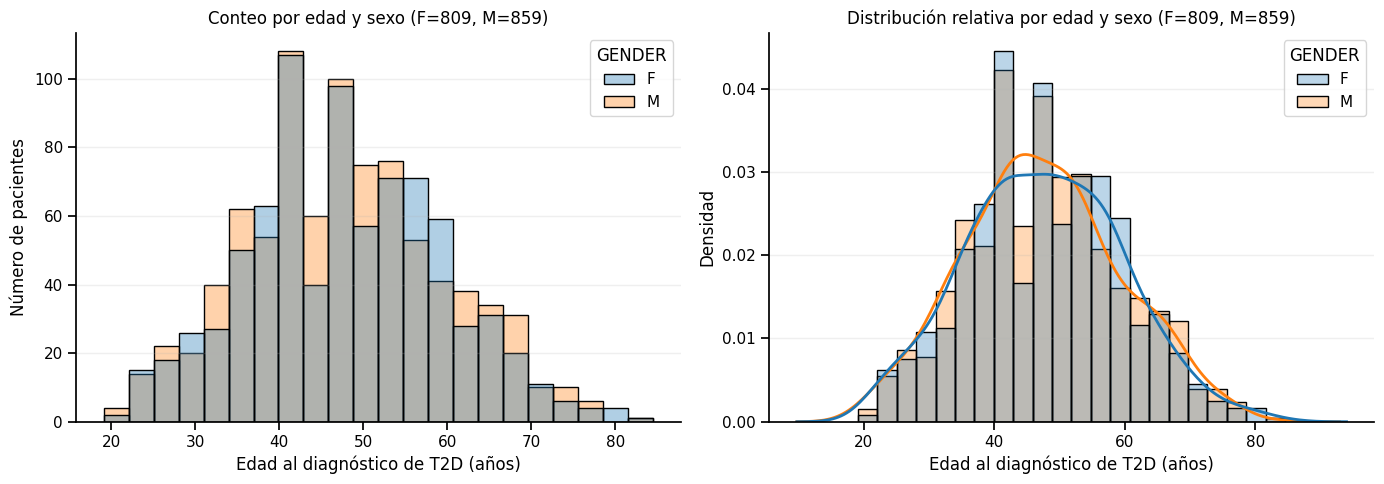

In [16]:
conteos = cohorte_adulta["GENDER"].value_counts()

n_f = conteos.get("F", 0)
n_m = conteos.get("M", 0)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(
    data=cohorte_adulta,
    x="edad_indice",
    hue="GENDER",
    bins=22,
    stat="count",
    multiple="layer",
    alpha=0.35,
    edgecolor="black",
    ax=axes[0]
)

axes[0].set(
    xlabel="Edad al diagnóstico de T2D (años)",
    ylabel="Número de pacientes",
    title=f"Conteo por edad y sexo (F={n_f:,}, M={n_m:,})"
)

sns.histplot(
    data=cohorte_adulta,
    x="edad_indice",
    hue="GENDER",
    bins=22,
    stat="density",
    common_norm=False,
    multiple="layer",
    alpha=0.30,
    edgecolor="black",
    ax=axes[1]
)

sns.kdeplot(
    data=cohorte_adulta,
    x="edad_indice",
    hue="GENDER",
    common_norm=False,
    linewidth=2,
    ax=axes[1],
    legend=False
)

axes[1].set(
    xlabel="Edad al diagnóstico de T2D (años)",
    ylabel="Densidad",
    title=f"Distribución relativa por edad y sexo (F={n_f:,}, M={n_m:,})"
)

for ax in axes:
    ax.spines[["top", "right"]].set_visible(False)
    ax.grid(axis="y", alpha=0.2)

fig.tight_layout()
plt.show()

### Resultado de la distribución de edad por sexo

La cohorte adulta incluye 809 mujeres y 859 hombres. En términos absolutos, el histograma de conteos muestra algunos intervalos con mayor número de hombres, lo cual está parcialmente influido por el mayor tamaño del grupo masculino.

Sin embargo, al normalizar cada grupo mediante densidad, la comparación cambia: las mujeres presentan una mayor concentración relativa alrededor de los 40–45 años, mientras que la distribución de los hombres alcanza su mayor densidad ligeramente después y muestra una concentración distinta a lo largo del rango de edad.

Esta diferencia entre ambas gráficas es esperable. El panel de conteos responde cuántos pacientes hay en cada intervalo, mientras que el panel de densidad describe cómo se distribuyen proporcionalmente las edades dentro de cada sexo, independientemente del tamaño total de cada grupo.

En conjunto, ambas distribuciones presentan un solapamiento considerable y una concentración principal de diagnósticos entre aproximadamente los 35 y 60 años, aunque existen diferencias locales en la forma de la distribución entre mujeres y hombres.

### 2.4 Evolución temporal de HbA1c

La hemoglobina glucosilada (HbA1c) se utilizará como analito principal para explorar la evolución temporal del control glucémico en la cohorte.

Primero se identificarán las observaciones correspondientes a HbA1c dentro del archivo `observations.csv` y posteriormente se analizará su distribución temporal con respecto a la fecha índice de diagnóstico de T2D.

In [17]:
matches = []

for chunk in pd.read_csv(
    DATA_DIR / "observations.csv",
    usecols=["CODE", "DESCRIPTION"],
    dtype="string",
    chunksize=500_000
):
    mask = chunk["DESCRIPTION"].str.contains(
        "A1c|glycated|glycosylated",
        case=False,
        na=False
    )

    matches.append(chunk.loc[mask].drop_duplicates())

hba1c_codigos = (
    pd.concat(matches)
    .drop_duplicates()
    .sort_values(["DESCRIPTION", "CODE"])
)

hba1c_codigos

,CODE,DESCRIPTION
1004,4548-4,Hemoglobin A1c/Hemoglobin.total in Blood


### 2.4 Evolución temporal de HbA1c

La hemoglobina glucosilada (HbA1c; LOINC `4548-4`) se utilizará como marcador principal para evaluar la evolución temporal del control glucémico.

Las mediciones se alinearán con respecto a la fecha índice de diagnóstico de T2D de cada paciente, de modo que el tiempo negativo represente mediciones previas al diagnóstico y el tiempo positivo mediciones posteriores.

In [18]:
HBA1C_CODE = "4548-4"
pacientes_t2d = set(cohorte_adulta["PATIENT"])

hba1c_chunks = []

for chunk in pd.read_csv(
    DATA_DIR / "observations.csv",
    usecols=["PATIENT", "DATE", "CODE", "DESCRIPTION", "VALUE", "UNITS"],
    dtype={"PATIENT": "string", "CODE": "string"},
    chunksize=500_000
):
    mask = chunk["PATIENT"].isin(pacientes_t2d) & (chunk["CODE"] == HBA1C_CODE)
    hba1c_chunks.append(chunk.loc[mask])

hba1c = pd.concat(hba1c_chunks, ignore_index=True)

hba1c["DATE"] = pd.to_datetime(hba1c["DATE"], utc=True).dt.tz_localize(None)
hba1c["VALUE"] = pd.to_numeric(hba1c["VALUE"], errors="coerce")

hba1c = hba1c.merge(
    cohorte_adulta[["PATIENT", "fecha_indice"]],
    on="PATIENT",
    how="left"
)

hba1c["fecha_indice"] = pd.to_datetime(hba1c["fecha_indice"]).dt.tz_localize(None)

hba1c["dias_desde_diagnostico"] = (hba1c["DATE"] - hba1c["fecha_indice"]).dt.days

print("Mediciones HbA1c:", len(hba1c))
print("Pacientes con HbA1c:", hba1c["PATIENT"].nunique())
print("Cobertura de la cohorte:", f"{100 * hba1c['PATIENT'].nunique() / len(cohorte_adulta):.1f}%")

print("\nUnidades:")
print(hba1c["UNITS"].value_counts(dropna=False))

print("\nResumen:")
print(hba1c[["VALUE", "dias_desde_diagnostico"]].describe().round(2))

Mediciones HbA1c: 66382
Pacientes con HbA1c: 1668
Cobertura de la cohorte: 100.0%

Unidades:
UNITS
%    66382
Name: count, dtype: int64

Resumen:
          VALUE  dias_desde_diagnostico
count  66382.00                66382.00
mean       4.25                 8433.18
std        1.37                 5561.26
min        2.30                -3346.00
25%        3.10                 4452.00
50%        3.90                 7679.00
75%        5.40                11795.00
max       10.20                27153.00


### Resultado inicial de las mediciones de HbA1c

Se identificaron 66,382 mediciones de HbA1c correspondientes a los 1,668 pacientes de la cohorte, lo que representa una cobertura del 100%. Todas las observaciones utilizan porcentaje (`%`) como unidad.

Los valores de HbA1c presentan una mediana de 3.9% y un rango de 2.3% a 10.2%.

El tiempo relativo al diagnóstico muestra un rango muy amplio, desde 3,346 días antes hasta 27,153 días después de la fecha índice. Esto indica que algunos pacientes cuentan con décadas de seguimiento simulado. Debido a esta amplitud, la evolución alrededor del diagnóstico podría quedar ocultada si se representa toda la historia clínica en una sola escala.

Por este motivo, primero se inspeccionará gráficamente la distribución temporal completa y después se utilizará una ventana centrada alrededor del diagnóstico para estudiar con mayor detalle la evolución de HbA1c.

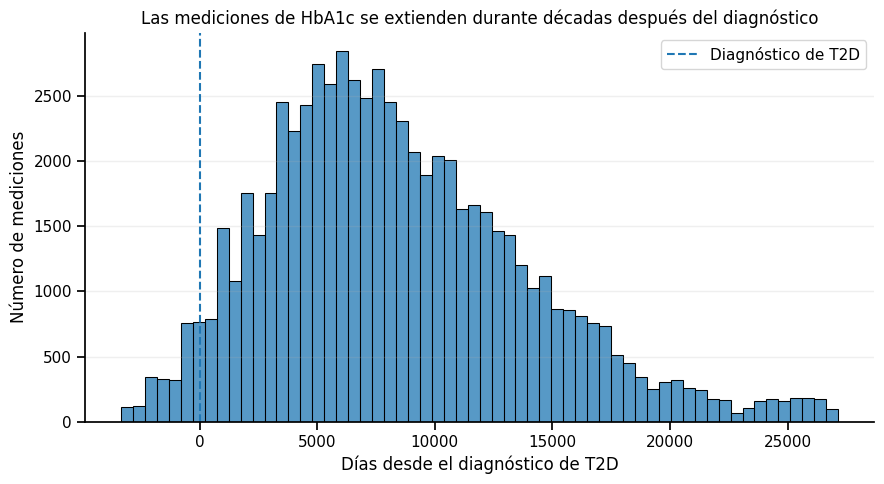

In [19]:
fig, ax = plt.subplots(figsize=(9, 5))

sns.histplot(data=hba1c, x="dias_desde_diagnostico", bins=60, ax=ax)

ax.axvline(0, linestyle="--", linewidth=1.5, label="Diagnóstico de T2D")

ax.set(
    xlabel="Días desde el diagnóstico de T2D",
    ylabel="Número de mediciones",
    title="Las mediciones de HbA1c se extienden durante décadas después del diagnóstico"
)

ax.legend()
ax.spines[["top", "right"]].set_visible(False)
ax.grid(axis="y", alpha=0.2)

fig.tight_layout()
plt.show()

### Resultado de la distribución temporal de HbA1c

Las mediciones de HbA1c presentan una distribución temporal marcadamente asimétrica. Existen observaciones antes del diagnóstico de T2D, pero la mayoría se concentra durante los años posteriores y el seguimiento se extiende durante varias décadas.

Esta amplitud temporal implica que el número de pacientes y de mediciones disponibles no es constante a lo largo del seguimiento. Por ello, comparar directamente todos los tiempos podría producir estimaciones dominadas por diferencias en la disponibilidad de datos.

Para estudiar la evolución alrededor del diagnóstico se utilizará una ventana temporal definida y se resumirá HbA1c por intervalos de tiempo.

Mediciones ±5 años: 5656
Pacientes: 800


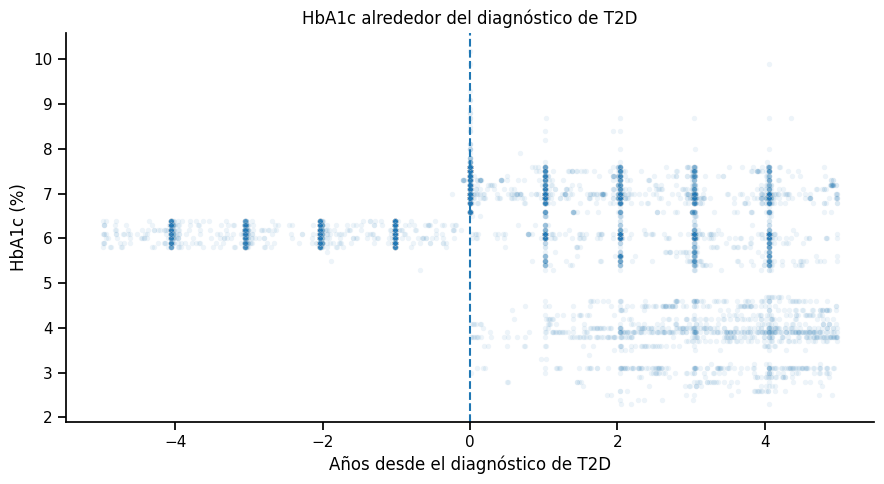

In [20]:
hba1c_5y = hba1c.loc[hba1c["dias_desde_diagnostico"].between(-1825, 1825)].copy()
hba1c_5y["anio_relativo"] = hba1c_5y["dias_desde_diagnostico"] / 365.25

print("Mediciones ±5 años:", len(hba1c_5y))
print("Pacientes:", hba1c_5y["PATIENT"].nunique())

fig, ax = plt.subplots(figsize=(9, 5))

sns.scatterplot(data=hba1c_5y, x="anio_relativo", y="VALUE", alpha=0.08, s=15, ax=ax)

ax.axvline(0, linestyle="--", linewidth=1.5)
ax.set(xlabel="Años desde el diagnóstico de T2D", ylabel="HbA1c (%)",
       title="HbA1c alrededor del diagnóstico de T2D")

ax.spines[["top", "right"]].set_visible(False)
fig.tight_layout()
plt.show()

### Resultado de HbA1c alrededor del diagnóstico

La distribución temporal de HbA1c cambia de forma marcada alrededor de la fecha índice. Antes del diagnóstico, las mediciones se concentran principalmente alrededor de 6%, con una dispersión relativamente pequeña.

Después del diagnóstico aumenta considerablemente la variabilidad y aparecen varias bandas horizontales de valores, aproximadamente alrededor de 3–4.5%, 5.5–6.5% y 7–7.5%. También se observan algunos valores superiores a 8%.

Este patrón no se aprecia mediante un resumen numérico global como `describe()`. La visualización revela una estructura discreta y repetitiva en las mediciones posteriores al diagnóstico, compatible con el carácter sintético de los datos de Synthea.

Por tanto, esta estructura se considerará un hallazgo de calidad de datos: las mediciones de HbA1c no forman una distribución continua completamente natural, sino que muestran agrupamientos y valores repetidos que deben tenerse en cuenta al interpretar tendencias clínicas.

### 2.5 Evolución temporal de HbA1c

Para reducir el efecto de mediciones individuales repetidas y de valores extremos, la evolución de HbA1c se resumirá por intervalos de seis meses utilizando la mediana y el rango intercuartílico (IQR).

Este enfoque permite observar la tendencia central y la variabilidad de HbA1c alrededor del diagnóstico sin asumir una distribución normal.

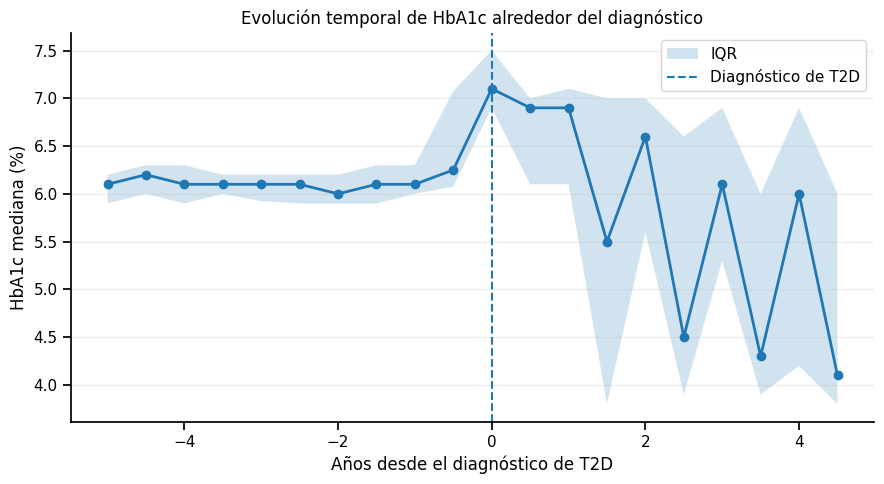

,semestre,n,mediana,q1,q3
0,-5.0,37,6.10,5.90,6.20
1,-4.5,258,6.20,6.00,6.30
2,-4.0,39,6.10,5.90,6.30
3,-3.5,283,6.10,6.00,6.20
4,-3.0,30,6.10,5.93,6.20
5,-2.5,350,6.10,5.90,6.20
6,-2.0,43,6.00,5.90,6.20
7,-1.5,360,6.10,5.90,6.30
8,-1.0,33,6.10,6.00,6.30
9,-0.5,28,6.25,6.07,7.08


In [21]:
hba1c_5y["semestre"] = np.floor(hba1c_5y["anio_relativo"] * 2) / 2

resumen_hba1c = (
    hba1c_5y.groupby("semestre", observed=True)["VALUE"]
    .agg(
        n="count",
        mediana="median",
        q1=lambda x: x.quantile(0.25),
        q3=lambda x: x.quantile(0.75)
    )
    .reset_index()
)

fig, ax = plt.subplots(figsize=(9, 5))

ax.plot(resumen_hba1c["semestre"], resumen_hba1c["mediana"], marker="o", linewidth=2)

ax.fill_between(
    resumen_hba1c["semestre"],
    resumen_hba1c["q1"],
    resumen_hba1c["q3"],
    alpha=0.2,
    label="IQR"
)

ax.axvline(0, linestyle="--", linewidth=1.5, label="Diagnóstico de T2D")

ax.set(
    xlabel="Años desde el diagnóstico de T2D",
    ylabel="HbA1c mediana (%)",
    title="Evolución temporal de HbA1c alrededor del diagnóstico"
)

ax.legend()
ax.spines[["top", "right"]].set_visible(False)
ax.grid(axis="y", alpha=0.2)

fig.tight_layout()
plt.show()

resumen_hba1c.round(2)

### Resultado de la evolución temporal de HbA1c

Antes del diagnóstico de T2D, la mediana de HbA1c se mantiene relativamente estable alrededor de 6.0–6.2%, con un rango intercuartílico estrecho.

En el periodo inmediatamente cercano al diagnóstico se observa un incremento de la mediana hasta aproximadamente 7.1%, acompañado de un aumento en la dispersión.

Después del diagnóstico, la variabilidad aumenta de forma marcada. Las medianas oscilan aproximadamente entre 4% y 7%, mientras que el IQR se amplía considerablemente en varios intervalos temporales.

Este comportamiento sugiere un cambio importante en la distribución de HbA1c después del diagnóstico. Sin embargo, las fluctuaciones tardías deben interpretarse con cautela, ya que pueden estar influenciadas por diferencias en el número de mediciones disponibles y por la estructura sintética observada previamente en los valores de HbA1c.

### 2.6 Comorbilidades más frecuentes

Se identificarán las condiciones más frecuentes registradas en los pacientes de la cohorte adulta con T2D. Para evitar sobrecontar diagnósticos repetidos, cada condición se contará una sola vez por paciente.

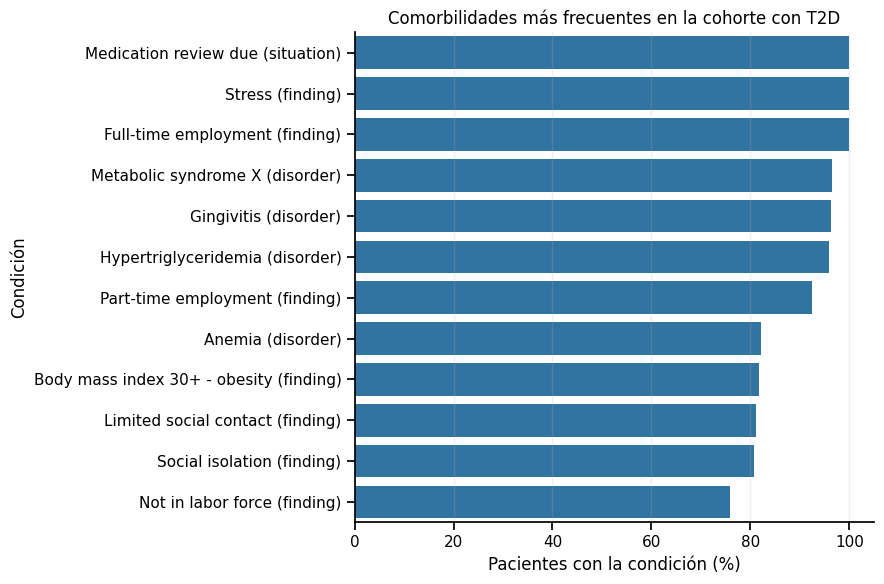

,DESCRIPTION,pacientes,porcentaje
0,Medication review due (situation),1668,100.0
1,Stress (finding),1667,99.9
2,Full-time employment (finding),1666,99.9
3,Metabolic syndrome X (disorder),1609,96.5
4,Gingivitis (disorder),1605,96.2
5,Hypertriglyceridemia (disorder),1600,95.9
6,Part-time employment (finding),1543,92.5
7,Anemia (disorder),1372,82.3
8,Body mass index 30+ - obesity (finding),1363,81.7
9,Limited social contact (finding),1354,81.2


In [22]:
cond_adulta = conditions.loc[conditions["PATIENT"].isin(cohorte_adulta["PATIENT"])].copy()

top_comorb = (
    cond_adulta.loc[cond_adulta["CODE"] != T2D_CODE]
    .groupby(["CODE", "DESCRIPTION"])["PATIENT"]
    .nunique()
    .sort_values(ascending=False)
    .head(12)
    .reset_index(name="pacientes")
)

top_comorb["porcentaje"] = 100 * top_comorb["pacientes"] / len(cohorte_adulta)

fig, ax = plt.subplots(figsize=(9, 6))

sns.barplot(data=top_comorb, y="DESCRIPTION", x="porcentaje", ax=ax)

ax.set(
    xlabel="Pacientes con la condición (%)",
    ylabel="Condición",
    title="Comorbilidades más frecuentes en la cohorte con T2D"
)

ax.spines[["top", "right"]].set_visible(False)
ax.grid(axis="x", alpha=0.2)

fig.tight_layout()
plt.show()

top_comorb[["DESCRIPTION", "pacientes", "porcentaje"]].round(1)

### Resultado inicial de comorbilidades y calidad semántica

La visualización inicial revela que `conditions.csv` no contiene exclusivamente enfermedades. Entre las categorías más frecuentes aparecen situaciones administrativas, laborales y sociales, como revisión de medicamentos, empleo de tiempo completo, contacto social limitado y aislamiento social.

Por tanto, interpretar directamente todas las filas de `conditions.csv` como comorbilidades produciría una clasificación clínicamente incorrecta. Este problema semántico no era evidente en los resúmenes numéricos generales y se hizo visible al inspeccionar gráficamente las condiciones más frecuentes.

Para obtener una representación más específica de comorbilidades clínicas, el análisis posterior se restringirá a registros identificados como `disorder`.

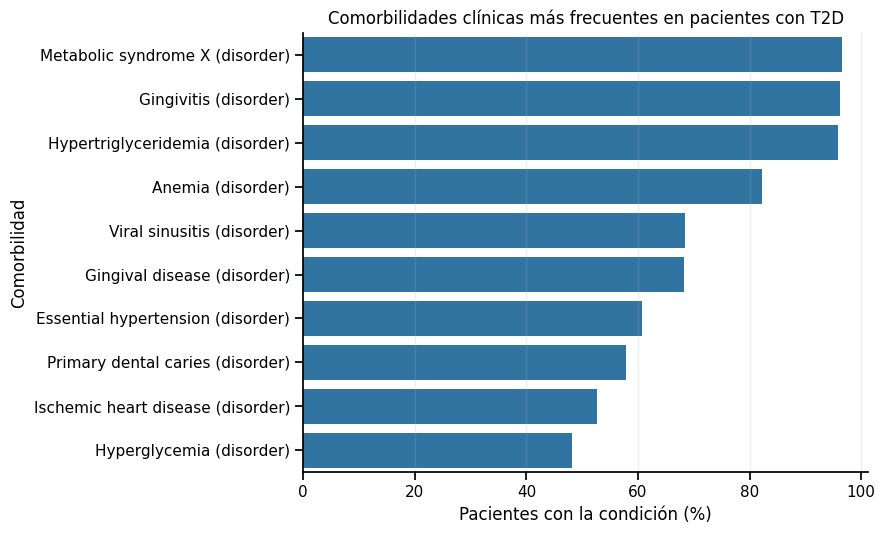

,DESCRIPTION,pacientes,porcentaje
0,Metabolic syndrome X (disorder),1609,96.5
1,Gingivitis (disorder),1605,96.2
2,Hypertriglyceridemia (disorder),1600,95.9
3,Anemia (disorder),1372,82.3
4,Viral sinusitis (disorder),1142,68.5
5,Gingival disease (disorder),1137,68.2
6,Essential hypertension (disorder),1012,60.7
7,Primary dental caries (disorder),966,57.9
8,Ischemic heart disease (disorder),878,52.6
9,Hyperglycemia (disorder),804,48.2


In [23]:
comorb = cond_adulta.loc[
    (cond_adulta["CODE"] != T2D_CODE)
    & cond_adulta["DESCRIPTION"].str.contains(r"\(disorder\)", case=False, na=False)
].copy()

top_comorb = (
    comorb.groupby(["CODE", "DESCRIPTION"])["PATIENT"]
    .nunique()
    .sort_values(ascending=False)
    .head(10)
    .reset_index(name="pacientes")
)

top_comorb["porcentaje"] = 100 * top_comorb["pacientes"] / len(cohorte_adulta)

fig, ax = plt.subplots(figsize=(9, 5.5))

sns.barplot(data=top_comorb, y="DESCRIPTION", x="porcentaje", ax=ax)

ax.set(
    xlabel="Pacientes con la condición (%)",
    ylabel="Comorbilidad",
    title="Comorbilidades clínicas más frecuentes en pacientes con T2D"
)

ax.spines[["top", "right"]].set_visible(False)
ax.grid(axis="x", alpha=0.2)

fig.tight_layout()
plt.show()

top_comorb[["DESCRIPTION", "pacientes", "porcentaje"]].round(1)

### Resultado de las comorbilidades clínicas

Después de restringir el análisis a condiciones identificadas como `disorder`, la distribución cambia de forma importante y se obtiene un perfil clínicamente más interpretable.

Las condiciones más frecuentes incluyen síndrome metabólico, gingivitis, hipertrigliceridemia, anemia, hipertensión esencial, cardiopatía isquémica e hiperglucemia. Varias de estas condiciones son consistentes con el contexto metabólico y cardiovascular de una cohorte con T2D.

La comparación con la visualización inicial muestra además que `conditions.csv` mezcla diagnósticos clínicos con situaciones administrativas, sociales y laborales. Esta contaminación semántica representa el segundo problema de calidad identificado gráficamente y justifica filtrar las categorías antes de interpretar comorbilidades.

### 2.7 Figura multipanel de resumen clínico

Se integran en una sola figura los principales hallazgos exploratorios de la cohorte: distribución de edad por sexo, comportamiento individual de HbA1c alrededor del diagnóstico, evolución temporal resumida de HbA1c y comorbilidades clínicas más frecuentes.

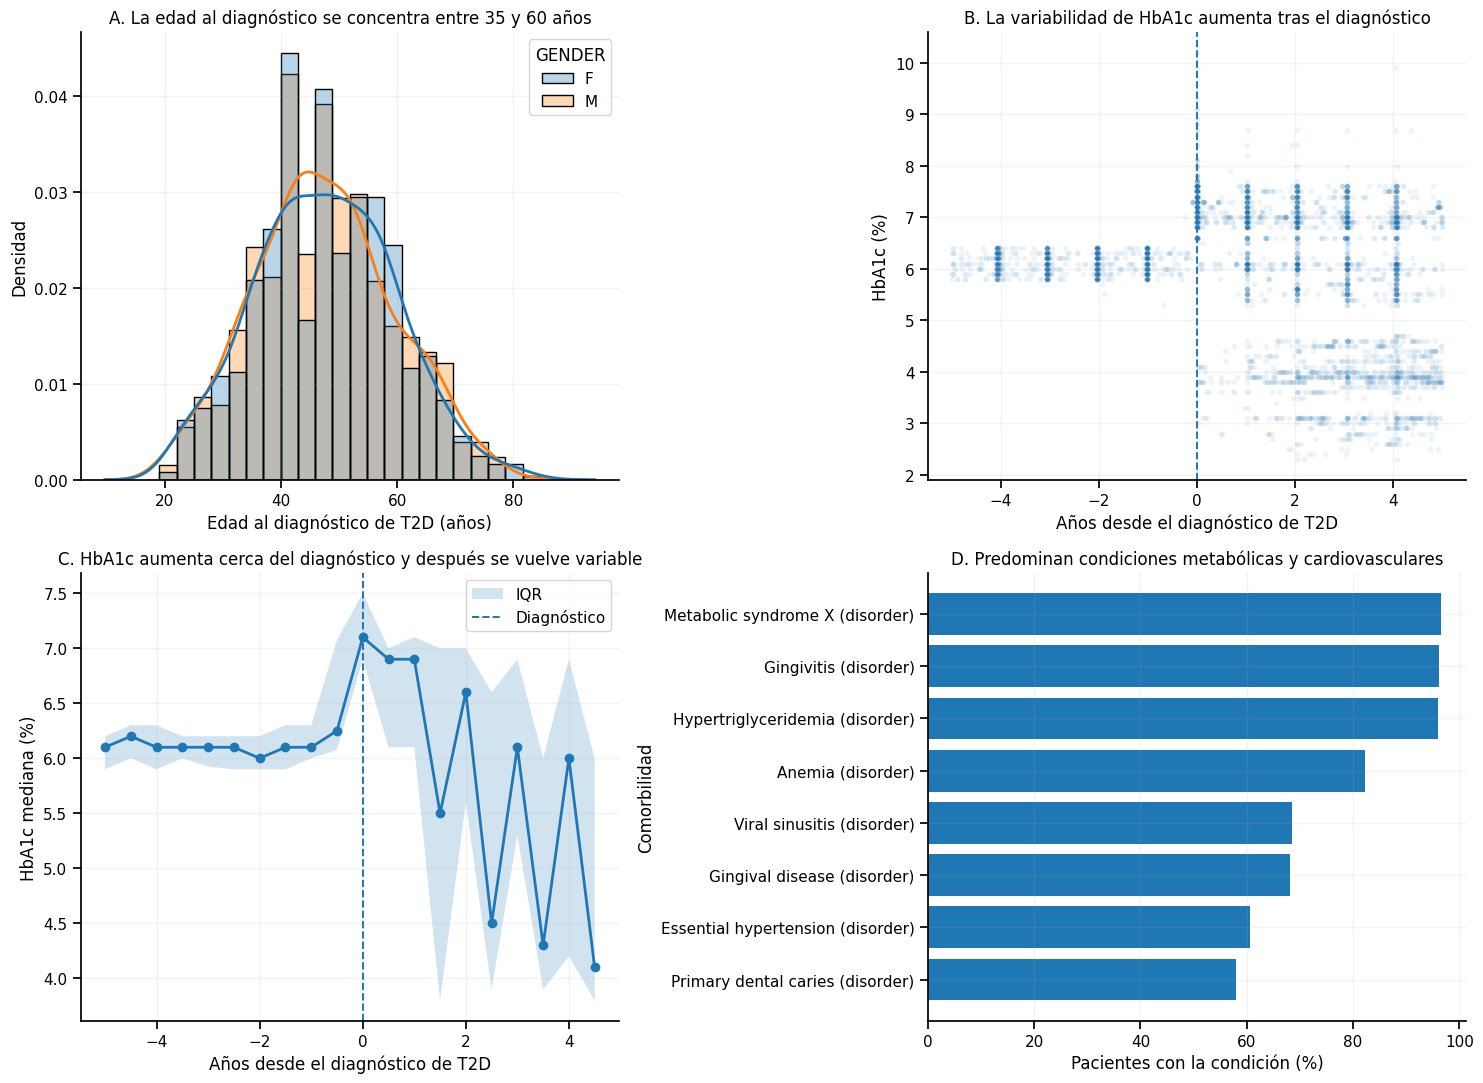

In [24]:
fig, axes = plt.subplots(2, 2, figsize=(15, 11))

# A. Edad por sexo
sns.histplot(
    data=cohorte_adulta, x="edad_indice", hue="GENDER",
    bins=22, stat="density", common_norm=False,
    multiple="layer", alpha=0.30, edgecolor="black",
    ax=axes[0, 0]
)
sns.kdeplot(
    data=cohorte_adulta, x="edad_indice", hue="GENDER",
    common_norm=False, linewidth=2, legend=False,
    ax=axes[0, 0]
)
axes[0, 0].set(
    xlabel="Edad al diagnóstico de T2D (años)",
    ylabel="Densidad",
    title="A. La edad al diagnóstico se concentra entre 35 y 60 años"
)

# B. HbA1c individual
sns.scatterplot(
    data=hba1c_5y, x="anio_relativo", y="VALUE",
    alpha=0.08, s=15, ax=axes[0, 1]
)
axes[0, 1].axvline(0, linestyle="--", linewidth=1.4)
axes[0, 1].set(
    xlabel="Años desde el diagnóstico de T2D",
    ylabel="HbA1c (%)",
    title="B. La variabilidad de HbA1c aumenta tras el diagnóstico"
)

# C. Evolución temporal
axes[1, 0].plot(
    resumen_hba1c["semestre"],
    resumen_hba1c["mediana"],
    marker="o",
    linewidth=2
)
axes[1, 0].fill_between(
    resumen_hba1c["semestre"],
    resumen_hba1c["q1"],
    resumen_hba1c["q3"],
    alpha=0.20,
    label="IQR"
)
axes[1, 0].axvline(0, linestyle="--", linewidth=1.4, label="Diagnóstico")
axes[1, 0].set(
    xlabel="Años desde el diagnóstico de T2D",
    ylabel="HbA1c mediana (%)",
    title="C. HbA1c aumenta cerca del diagnóstico y después se vuelve variable"
)
axes[1, 0].legend()

# D. Comorbilidades
top_plot = top_comorb.head(8).sort_values("porcentaje")

axes[1, 1].barh(
    top_plot["DESCRIPTION"],
    top_plot["porcentaje"]
)
axes[1, 1].set(
    xlabel="Pacientes con la condición (%)",
    ylabel="Comorbilidad",
    title="D. Predominan condiciones metabólicas y cardiovasculares"
)

for ax in axes.flat:
    ax.spines[["top", "right"]].set_visible(False)
    ax.grid(alpha=0.15)

fig.tight_layout()

fig.savefig("figuras/figura_resumen_eda.png", dpi=300, bbox_inches="tight")
fig.savefig("figuras/figura_resumen_eda.pdf", bbox_inches="tight")

plt.show()

### 2.8 Table 1 — características basales

Se resumen las principales características basales de la cohorte adulta con T2D, estratificadas por sexo. Para variables continuas se reportan mediana e IQR; para variables categóricas, frecuencia y porcentaje.

In [25]:
tabla1 = []

for sexo in ["F", "M"]:
    sub = cohorte_adulta.loc[cohorte_adulta["GENDER"] == sexo]

    tabla1.append({
        "Grupo": sexo,
        "N": len(sub),
        "Edad, mediana (IQR)": f"{sub['edad_indice'].median():.1f} ({sub['edad_indice'].quantile(.25):.1f}-{sub['edad_indice'].quantile(.75):.1f})",
        "Casados/as, n (%)": f"{(sub['MARITAL'] == 'M').sum()} ({100*(sub['MARITAL'] == 'M').mean():.1f}%)"
    })

table1 = pd.DataFrame(tabla1)
table1

,Grupo,N,"Edad, mediana (IQR)","Casados/as, n (%)"
0,F,809,48.0 (40.0-56.1),444 (54.9%)
1,M,859,46.1 (39.8-55.1),474 (55.2%)


In [26]:
comorb_table = (
    comorb.groupby(["DESCRIPTION", "PATIENT"])
    .size()
    .reset_index()
    .drop_duplicates(["DESCRIPTION", "PATIENT"])
)

seleccion = [
    "Metabolic syndrome X (disorder)",
    "Hypertriglyceridemia (disorder)",
    "Essential hypertension (disorder)"
]

for enfermedad in seleccion:
    pacientes_enf = set(
        comorb_table.loc[
            comorb_table["DESCRIPTION"] == enfermedad,
            "PATIENT"
        ]
    )

    for sexo in ["F", "M"]:
        ids = cohorte_adulta.loc[cohorte_adulta["GENDER"] == sexo, "PATIENT"]
        n = ids.isin(pacientes_enf).sum()
        total = len(ids)

        table1.loc[table1["Grupo"] == sexo, enfermedad] = f"{n} ({100*n/total:.1f}%)"

table1

,Grupo,N,"Edad, mediana (IQR)","Casados/as, n (%)",Metabolic syndrome X (disorder),Hypertriglyceridemia (disorder),Essential hypertension (disorder)
0,F,809,48.0 (40.0-56.1),444 (54.9%),784 (96.9%),780 (96.4%),493 (60.9%)
1,M,859,46.1 (39.8-55.1),474 (55.2%),825 (96.0%),820 (95.5%),519 (60.4%)


In [27]:
# RENOMBRE DE COLUMNAS PARA PRESENTACIÓN
table1 = table1.rename(columns={
    "Grupo": "Sexo",
    "Metabolic syndrome X (disorder)": "Síndrome metabólico, n (%)",
    "Hypertriglyceridemia (disorder)": "Hipertrigliceridemia, n (%)",
    "Essential hypertension (disorder)": "Hipertensión esencial, n (%)"
})

table1

,Sexo,N,"Edad, mediana (IQR)","Casados/as, n (%)","Síndrome metabólico, n (%)","Hipertrigliceridemia, n (%)","Hipertensión esencial, n (%)"
0,F,809,48.0 (40.0-56.1),444 (54.9%),784 (96.9%),780 (96.4%),493 (60.9%)
1,M,859,46.1 (39.8-55.1),474 (55.2%),825 (96.0%),820 (95.5%),519 (60.4%)


### Resultado de la Table 1

La cohorte incluye 809 mujeres y 859 hombres. La edad al diagnóstico fue similar entre ambos grupos, con una mediana de 48.0 años en mujeres y 46.1 años en hombres.

La proporción de pacientes casados también fue prácticamente equivalente: 54.9% en mujeres y 55.2% en hombres.

Las comorbilidades seleccionadas presentaron prevalencias muy similares entre sexos. El síndrome metabólico estuvo presente en aproximadamente 96–97% de la cohorte, la hipertrigliceridemia en 95–96% y la hipertensión esencial en alrededor de 60%.

En conjunto, no se observan diferencias basales marcadas entre mujeres y hombres para estas características.

### 2.9 Comparación entre Matplotlib, Seaborn y Plotly

La distribución de edad por sexo se reproduce utilizando tres librerías diferentes. El objetivo no es cambiar la pregunta clínica, sino comparar el esfuerzo de implementación, el nivel de control y el tipo de salida que ofrece cada herramienta.

In [28]:
import sys
!{sys.executable} -m pip install -U nbformat ipython
import nbformat
print(nbformat.__version__)

5.11.1


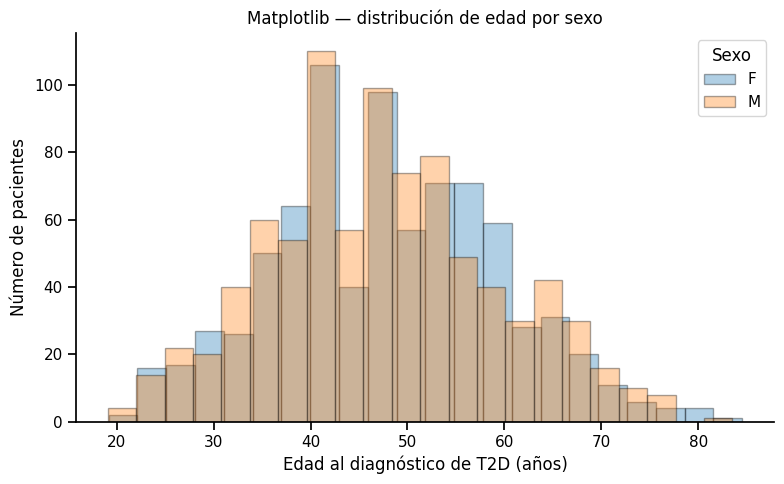

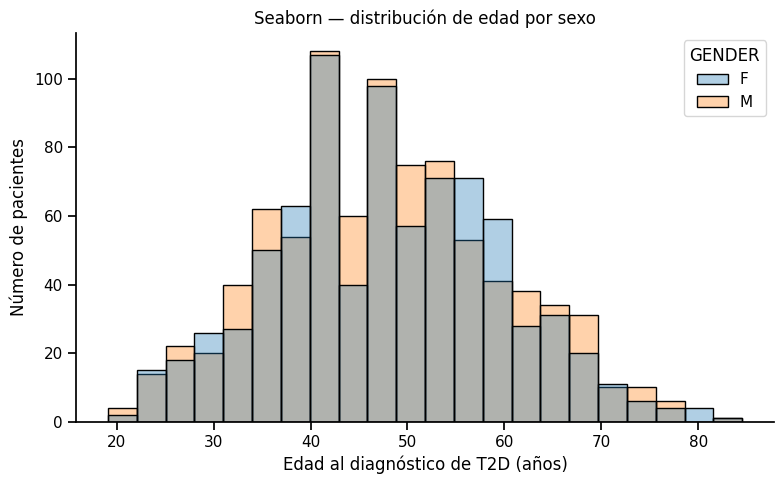

In [29]:
# MATPLOTLIB
fig, ax = plt.subplots(figsize=(8, 5))

for sexo in ["F", "M"]:
    datos = cohorte_adulta.loc[cohorte_adulta["GENDER"] == sexo, "edad_indice"]
    ax.hist(datos, bins=22, alpha=0.35, edgecolor="black", label=sexo)

ax.set(
    xlabel="Edad al diagnóstico de T2D (años)",
    ylabel="Número de pacientes",
    title="Matplotlib — distribución de edad por sexo"
)

ax.legend(title="Sexo")
ax.spines[["top", "right"]].set_visible(False)
fig.tight_layout()
plt.show()


# SEABORN
fig, ax = plt.subplots(figsize=(8, 5))

sns.histplot(
    data=cohorte_adulta,
    x="edad_indice",
    hue="GENDER",
    bins=22,
    multiple="layer",
    alpha=0.35,
    edgecolor="black",
    ax=ax
)

ax.set(
    xlabel="Edad al diagnóstico de T2D (años)",
    ylabel="Número de pacientes",
    title="Seaborn — distribución de edad por sexo"
)

ax.spines[["top", "right"]].set_visible(False)
fig.tight_layout()
plt.show()


# PLOTLY
fig = px.histogram(
    cohorte_adulta,
    x="edad_indice",
    color="GENDER",
    nbins=22,
    barmode="overlay",
    opacity=0.45,
    labels={
        "edad_indice": "Edad al diagnóstico de T2D (años)",
        "GENDER": "Sexo",
        "count": "Número de pacientes"
    },
    title="Plotly — distribución de edad por sexo"
)

fig.update_layout(
    xaxis_title="Edad al diagnóstico de T2D (años)",
    yaxis_title="Número de pacientes"
)

fig.show()